In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/bmidataset")

print("Path to dataset files:", path)

100%|██████████| 2.19k/2.19k [00:00<00:00, 3.38MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/bmidataset/versions/1


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bmi.csv to bmi.csv


In [ ]:
df = pd.read_csv('bmi.csv')

df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Height,500.0,169.944,16.375261,140.0,156.0,170.5,184.0,199.0
Weight,500.0,106.000,32.382607,50.0,80.0,106.0,136.0,160.0
Index,500.0,3.748,1.355053,0.0,3.0,4.0,5.0,5.0


In [ ]:
df.isnull().sum()

,0
Gender,0
Height,0
Weight,0
Index,0


In [ ]:
df["BMI"] = round(df["Weight"]/((df["Height"])/100)**2, 2)   #Weight(Kg)/Height(m)^2
df.head()

,Gender,Height,Weight,Index,BMI
0,Male,174,96,4,31.71
1,Male,189,87,2,24.36
2,Female,185,110,4,32.14
3,Female,195,104,3,27.35
4,Male,149,61,3,27.48


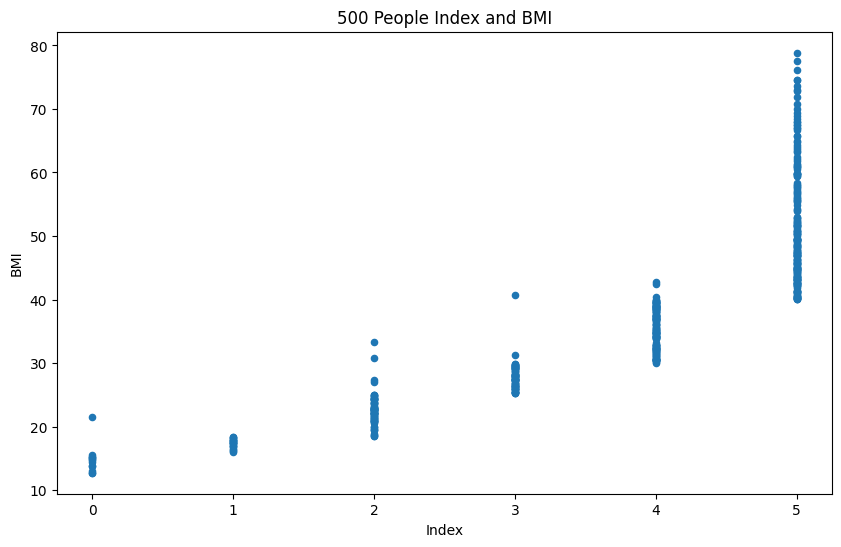

In [ ]:
df.plot(x="Index", y="BMI", kind="scatter",
        figsize=(10,6),
        title="500 People Index and BMI");

In [ ]:
# def index(x):
#     if x["BMI"] <18.5:
#         return 0
#     elif 18.5<= x["BMI"] < 25:
#         return 1
#     elif 25<= x["BMI"] < 30:
#         return 2
#     elif 30<= x["BMI"] < 35:
#         return 3
#     elif 35<= x["BMI"] < 40:
#         return 4
#     elif x["BMI"] >= 40:
#         return 5
# df["New_Index"] = df.apply(index, axis=1)
# df.head()
def index(x):
    if x["BMI"] < 25:
        return 0  # 正常或偏瘦
    else:
        return 1  # 超重及肥胖
df["New_Index"] = df.apply(index, axis=1)
df.head()

,Gender,Height,Weight,Index,BMI,New_Index
0,Male,174,96,4,31.71,1
1,Male,189,87,2,24.36,0
2,Female,185,110,4,32.14,1
3,Female,195,104,3,27.35,1
4,Male,149,61,3,27.48,1


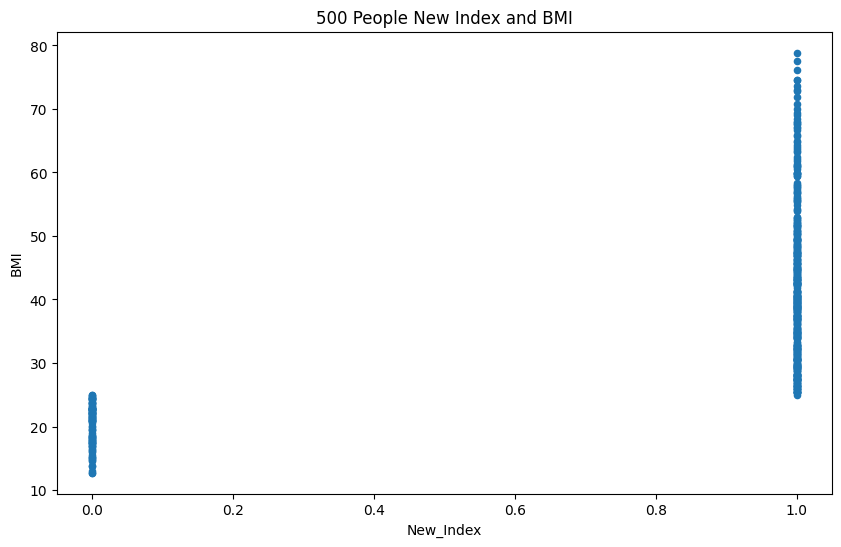

In [ ]:
df.plot(x='New_Index', y='BMI', kind='scatter',
        figsize=(10,6),
        title='500 People New Index and BMI');

In [ ]:
def status(x):
    if x["New_Index"] == 0:
        return "Underweight and healthy"
    elif x["New_Index"] == 1:
        return "Overweight"
df["Status"] = df.apply(status, axis=1)
df.head()

,Gender,Height,Weight,Index,BMI,New_Index,Status
0,Male,174,96,4,31.71,1,Overweight
1,Male,189,87,2,24.36,0,Underweight and healthy
2,Female,185,110,4,32.14,1,Overweight
3,Female,195,104,3,27.35,1,Overweight
4,Male,149,61,3,27.48,1,Overweight


In [ ]:
df.drop(["Index"],axis=1,inplace = True)

In [ ]:
df.head()

,Gender,Height,Weight,BMI,New_Index,Status
0,Male,174,96,31.71,1,Overweight
1,Male,189,87,24.36,0,Underweight and healthy
2,Female,185,110,32.14,1,Overweight
3,Female,195,104,27.35,1,Overweight
4,Male,149,61,27.48,1,Overweight


In [ ]:
multi = df.set_index(["Gender", "New_Index", "Status"]).sort_index()
multi

Height  Weight    BMI
Gender New_Index Status                                        
Female 0         Underweight and healthy     172      67  22.65
                 Underweight and healthy     195      65  17.09
                 Underweight and healthy     185      81  23.67
                 Underweight and healthy     176      54  17.43
                 Underweight and healthy     191      54  14.80
...                                          ...     ...    ...
Male   1         Overweight                  173     111  37.09
                 Overweight                  198     136  34.69
                 Overweight                  152      98  42.42
                 Overweight                  150      95  42.22
                 Overweight                  173     131  43.77

[500 rows x 3 columns]

### Machine Learning

In [ ]:
%matplotlib inline

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [ ]:
X = df.drop(["New_Index", "Gender", "Status"], axis=1)
y = df["New_Index"]

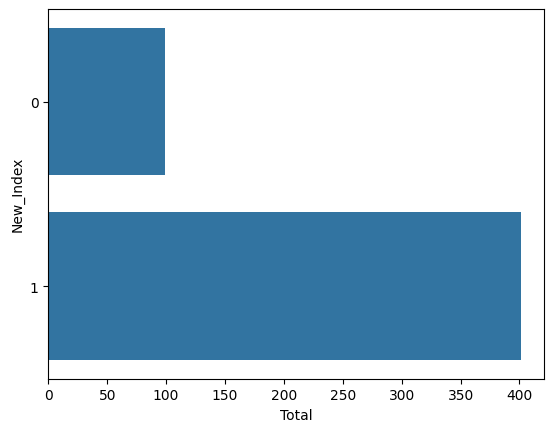

In [ ]:
sns.countplot(y=y, data=df)
plt.ylabel("New_Index")
plt.xlabel("Total")
plt.show()

In [ ]:
X = MinMaxScaler().fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
X_train

array([[0.3220339 , 0.94545455, 0.72874433],
       [0.45762712, 0.93636364, 0.63706505],
       [0.6440678 , 0.60909091, 0.36580938],
       ...,
       [0.10169492, 0.49090909, 0.54523449],
       [0.69491525, 0.55454545, 0.31966717],
       [0.45762712, 0.91818182, 0.62617247]])

In [ ]:
y_train

,New_Index
107,1
336,1
71,1
474,1
6,1
...,...
323,1
192,1
117,1
47,1


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 3), (100, 3), (400,), (100,))

In [ ]:
import math
import numpy as np

def sigmoid(X):
    return 1 / (1 + np.exp(-X))
def log_loss(y, y_):
    return -1*(y*math.log(sigmoid(y_)) + (1-y)*math.log(1-sigmoid(y_)))
def cal_grad(y,y_,x):
    return (y - sigmoid(y_)) * (x.reshape(-1, 1))

In [ ]:
# adam optimizer
# https://arxiv.org/abs/1412.6980
def train(X, Y, epochs = 500):

    # These values are taken as per the research paper
    alpha = 0.01
    beta_1 = 0.9
    beta_2 = 0.99

    M = X.shape[0]
    N = X.shape[1]
    w = np.random.uniform(-1, 1, size = N).reshape(N, 1)
    epsilon = 1e-8

    m_t = 0
    v_t = 0
    iter = 0
    cnt =0
    for epoch in range(1, epochs+1):
        cnt+=1
        for i in range(M):
            iter+=1
            y = Y.iloc[i]
            y_ = np.dot(w.T, X[i].reshape(N, 1))
            g_t = -(1.0/M)*cal_grad(y,y_,X[i])

            m_t = beta_1*m_t + (1-beta_1)*g_t
            v_t = beta_2*v_t + (1-beta_2)*(g_t*g_t)
            m_hat = m_t/(1-(beta_1**iter))
            v_hat = v_t/(1-(beta_2**iter))
            w_prev = w

            w = w - (alpha*m_hat)/(np.sqrt(v_hat)+epsilon)

        if epoch % 100 == 0:
            print(log_loss(y, y_))
        if(log_loss(y,y_) < 1e-10):
            break

    print("Converged at Epoch Number {} and total iteration done = {}".format(cnt, iter))

    return w

In [ ]:
w = train(X_train, y_train, epochs = 1000)

/tmp/ipython-input-27-3402633373.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -1*(y*math.log(sigmoid(y_)) + (1-y)*math.log(1-sigmoid(y_)))


Converged at Epoch Number 82 and total iteration done = 32800


In [ ]:
def predict(X):
    y_pred = []
    for i in range(len(X)):
        y_pred.append(np.round(sigmoid(np.dot(w.T, X[i].reshape(X.shape[1], 1)))))
    return y_pred

In [ ]:
y_pred = predict(X_test)

In [ ]:
print(y_pred[:5])         # 看看是不是类似 [0.72, 0.12, 0.91, ...]
y_pred = np.array(y_pred).flatten()            # 保证是扁平的一维向量
y_pred_label = (y_pred > 0.5).astype(int)      # 转成 0/1 标签
print(y_pred_label[:5])   # 转换后会变成 [1, 0, 1, ...]

[array([[1.]]), array([[1.]]), array([[1.]]), array([[1.]]), array([[1.]])]
[1 1 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, roc_curve
y_test = y_test.astype(int)
print("accuracy :", accuracy_score(y_test, y_pred_label))

accuracy : 0.99


In [ ]:
# original gradient descent
import numpy as np

def sigmoid(X):
    return 1 / (1 + np.exp(-X))

def log_loss(y, y_):
    return -1 * (y * np.log(sigmoid(y_)) + (1 - y) * np.log(1 - sigmoid(y_)))

def cal_grad(y, y_, x):
    return (y - sigmoid(y_)) * x.reshape(-1, 1)

def train_gd(X, Y, epochs=500, alpha=0.01):
    M = X.shape[0]
    N = X.shape[1]
    w = np.random.uniform(-1, 1, size=N).reshape(N, 1)  # 初始化权重

    for epoch in range(1, epochs + 1):
        for i in range(M):
            y = Y[i]
            x_i = X[i]
            y_ = np.dot(w.T, x_i.reshape(N, 1))
            grad = -(1.0 / M) * cal_grad(y, y_, x_i)
            w -= alpha * grad  # 权重更新公式（最普通的）

        # 每100轮打印一次损失
        if epoch % 100 == 0:
            loss = log_loss(y, y_)
            print(f"Epoch {epoch} | Loss: {loss}")

        # 如果损失足够小，就提前停止
        if log_loss(y, y_) < 1e-10:
            print(f"Early stop at epoch {epoch}")
            break

    return w

In [ ]:
w_gd = train(X_train, y_train, epochs = 1000)

Converged at Epoch Number 82 and total iteration done = 32800


In [ ]:
def predict(X):
    y_pred = []
    for i in range(len(X)):
        y_pred.append(np.round(sigmoid(np.dot(w.T, X[i].reshape(X.shape[1], 1)))))
    return y_pred

In [ ]:
y_pred_gd = predict(X_test)

In [ ]:
y_pred_gd = np.array(y_pred).flatten()            # 保证是扁平的一维向量
y_pred_gd_label = (y_pred > 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, roc_curve
y_test = y_test.astype(int)
print("accuracy :", accuracy_score(y_test, y_pred_gd_label))

accuracy : 0.99
